In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd


KSC_DIR = Path("~").expanduser() / "Dropbox" / "KSC_paper"
import subprocess

def get_repo_root():
    return Path(
        subprocess.check_output(
            ["git", "rev-parse", "--show-toplevel"],
            text=True
        ).strip()
    )

repo_dir = get_repo_root()
print(repo_dir)


/Volumes/PulwtopHome/Developer/GitHub/KSCRocketSeismoHydrology


In [2]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------
csvfile = repo_dir / "4_event_catalog" / "merged_launches.csv"
output_dir = KSC_DIR / "launch_plots"
output_dir.mkdir(exist_ok=True)

YEAR_MIN = 2016
YEAR_MAX = 2022
MIN_COUNT_FOR_OWN_CATEGORY = 1


# -----------------------------------------------------------------------------
# Helpers
# -----------------------------------------------------------------------------
def normalize_slc(value: str) -> str:
    """
    Normalize launch pad / SLC names into a cleaner, more consistent form.
    """
    if pd.isna(value):
        return "Unknown"

    s = str(value).strip().upper()
    s = s.replace("LC-", "")
    s = s.replace("SLC-", "")
    s = s.replace("LC ", "")
    s = s.replace("SLC ", "")
    s = s.replace("COMPLEX ", "")
    s = s.strip()

    replacements = {
        "39A": "SLC-39A",
        "39B": "SLC-39B",
        "40": "SLC-40",
        "41": "SLC-41",
        "37B": "SLC-37B",
        "37": "SLC-37",
        "36": "SLC-36",
        "46": "SLC-46",
        "17A": "SLC-17A",
        "17B": "SLC-17B",
        "13": "SLC-13",
        "11": "SLC-11",
        "12": "SLC-12",
    }
    return replacements.get(s, s)


def classify_rocket_family(mission: str) -> str:
    """
    Classify rocket family from mission string.
    """
    if pd.isna(mission):
        return "Unknown"

    s = str(mission).strip()
    s_lower = s.lower()

    patterns = [
        (r"falcon\s*heavy", "Falcon Heavy"),
        (r"falcon\s*9", "Falcon 9"),
        (r"atlas\s*v", "Atlas V"),
        (r"atlas\b", "Atlas"),
        (r"delta\s*iv", "Delta IV"),
        (r"delta\s*ii", "Delta II"),
        (r"artemis", "Artemis / SLS"),
        (r"\bsls\b", "Artemis / SLS"),
        (r"new\s*glenn", "New Glenn"),
        (r"vulcan", "Vulcan"),
        (r"minotaur\s*iv", "Minotaur IV"),
        (r"astra\s*rocket\s*3", "Astra Rocket 3"),
        (r"orion\s*test\s*booster", "Orion Test Booster"),
        (r"ariane\s*5", "Ariane 5"),
        (r"ariane\s*6", "Ariane 6"),
        (r"starliner", "Atlas V"),
        (r"crew[- ]?\d+", "Falcon 9"),
        (r"dragon", "Falcon 9"),
        (r"starlink", "Falcon 9"),
        (r"gps\s*iii", "Falcon 9"),
        (r"shuttle|sts-", "Space Shuttle"),
    ]

    for pattern, family in patterns:
        if re.search(pattern, s_lower):
            return family

    return s.split("|")[0].strip()


def classify_family_pad(row: pd.Series) -> str:
    """
    Build a combined family/pad category.

    Falcon 9 is split by SLC-40 and SLC-39A.
    Rocket families that are effectively tied to one pad remain distinct naturally.
    Rare categories can later be grouped to 'Other'.
    """
    fam = row["rocket_family"]
    slc = row["SLC_clean"]

    if fam == "Falcon 9":
        if slc == "SLC-40":
            return "Falcon 9 / SLC-40"
        if slc == "SLC-39A":
            return "Falcon 9 / SLC-39A"
        return f"Falcon 9 / {slc}"

    # Keep these explicit
    if fam in {"Falcon Heavy", "Atlas V", "Delta IV", "Artemis / SLS"}:
        return fam

    # Track SLC-46 launches distinctly
    if slc == "SLC-46":
        return f"{fam} / SLC-46"

    return fam


def group_small_categories(series: pd.Series, min_count: int = 3, other_label: str = "Other") -> pd.Series:
    """
    Replace categories with fewer than min_count occurrences by other_label.
    """
    counts = series.value_counts()
    keep = counts[counts >= min_count].index
    return series.where(series.isin(keep), other_label)


# -----------------------------------------------------------------------------
# Load and clean
# -----------------------------------------------------------------------------
df = pd.read_csv(csvfile)

first_five_cols = list(df.columns[:5])
print("Using duplicate key columns:", first_five_cols)

df["window_start"] = pd.to_datetime(df["window_start"], utc=True, errors="coerce")
df = df.dropna(subset=["window_start"]).copy()

df["year"] = df["window_start"].dt.year
df = df[(df["year"] >= YEAR_MIN) & (df["year"] <= YEAR_MAX)].copy()

before = len(df)
df = df.drop_duplicates(subset=first_five_cols, keep="first").copy()
after = len(df)
print(f"Filtered to {YEAR_MIN}-{YEAR_MAX}: {before} rows before dedupe, {after} after dedupe.")

df = df.sort_values("window_start").reset_index(drop=True)

df["SLC_clean"] = df["SLC"].apply(normalize_slc)
df["rocket_family"] = df["mission"].apply(classify_rocket_family)
df["family_pad"] = df.apply(classify_family_pad, axis=1)

# Group small family/pad categories into Other
df["family_pad_grouped"] = group_small_categories(
    df["family_pad"],
    min_count=MIN_COUNT_FOR_OWN_CATEGORY,
    other_label="Other",
)

df["cumulative_launches"] = range(1, len(df) + 1)

cleaned_csv = output_dir / f"launches_{YEAR_MIN}_{YEAR_MAX}_deduped.csv"
df.to_csv(cleaned_csv, index=False)
print(f"Saved cleaned CSV to: {cleaned_csv}")


# -----------------------------------------------------------------------------
# Summary tables
# -----------------------------------------------------------------------------
rename_map = {
    "Artemis / SLS": "Artemis / SLC-39B",
    "Delta IV": "Delta IV / SLC-37B",
    "Atlas V": "Atlas V / SLC-41",
}

df = df.copy()
df["family_pad_grouped"] = df["family_pad_grouped"].replace(rename_map)

launches_by_year = (
    df.groupby("year")
    .size()
    .rename("n_launches")
    .reset_index()
)

df_slc = df[df["family_pad_grouped"].str.contains("SLC", case=False, na=False)].copy()

launches_by_family_pad = (
    df_slc.groupby("family_pad_grouped")
    .size()
    .rename("n_launches")
    .sort_values(ascending=False)
    .reset_index()
)



Using duplicate key columns: ['launch_designator', 'window_start', 'window_end', 'mission', 'SLC']
Filtered to 2016-2022: 214 rows before dedupe, 195 after dedupe.
Saved cleaned CSV to: /Users/GlennThompson/Dropbox/KSC_paper/launch_plots/launches_2016_2022_deduped.csv


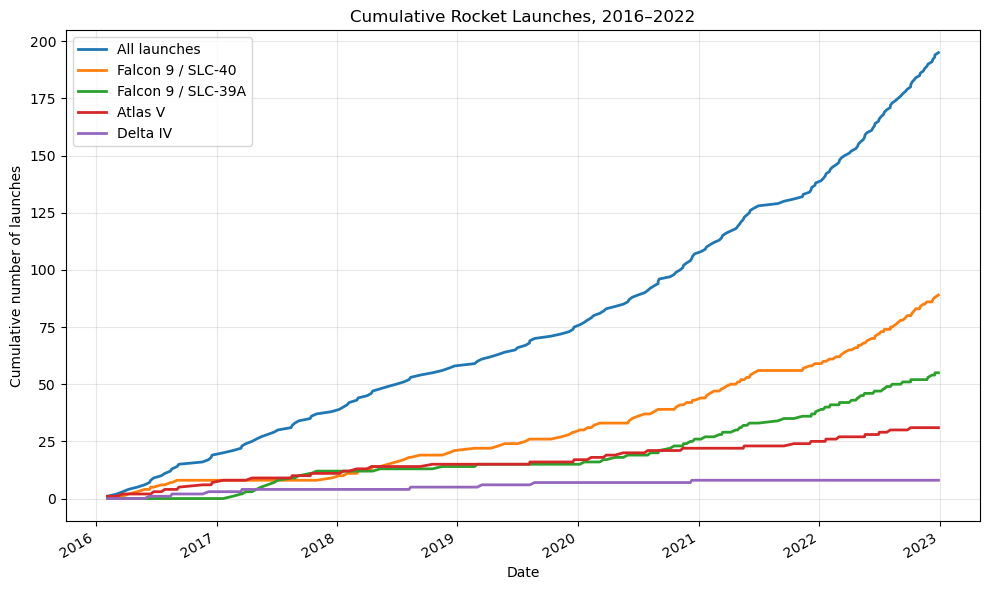

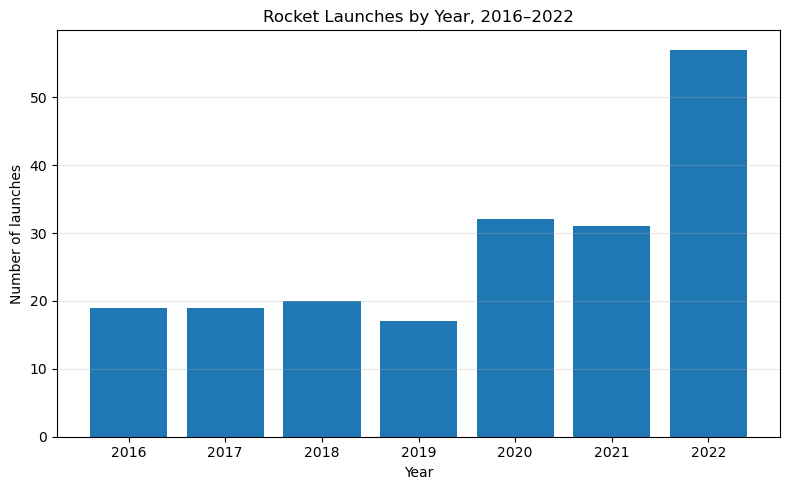

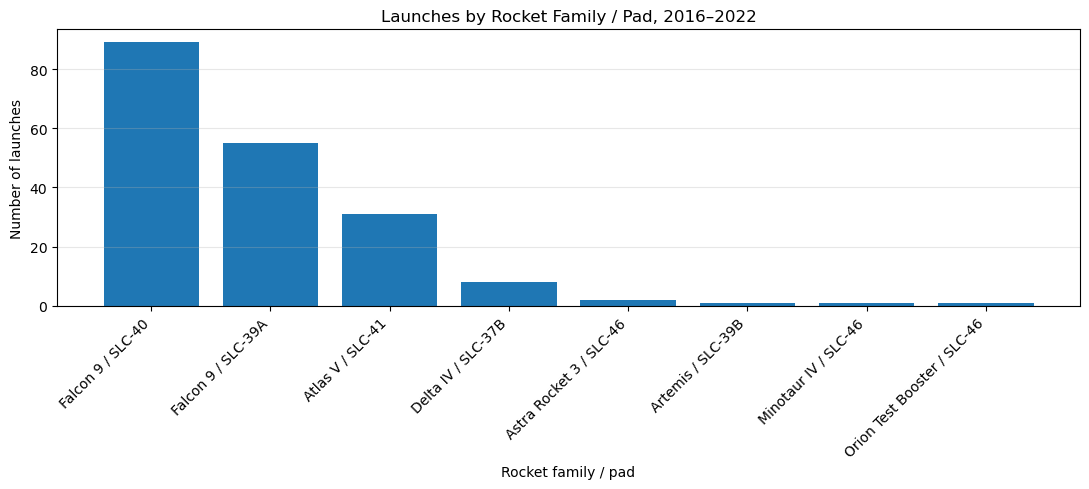

In [3]:
# -----------------------------------------------------------------------------
# Plot 1: cumulative launches through time, with selected families
# -----------------------------------------------------------------------------
df_plot = df.sort_values("window_start").copy()

curve_defs = {
    "All launches": pd.Series(True, index=df_plot.index),
    "Falcon 9 / SLC-40": df_plot["family_pad"] == "Falcon 9 / SLC-40",
    "Falcon 9 / SLC-39A": df_plot["family_pad"] == "Falcon 9 / SLC-39A",
    "Atlas V": df_plot["rocket_family"] == "Atlas V",
    "Delta IV": df_plot["rocket_family"] == "Delta IV",
}

curve_cols = {}
for label, mask in curve_defs.items():
    col = "cum_" + re.sub(r"[^A-Za-z0-9]+", "_", label).strip("_")
    df_plot[col] = mask.astype(int).cumsum()
    curve_cols[label] = col

fig, ax = plt.subplots(figsize=(10, 6))
for label in curve_defs:
    ax.plot(df_plot["window_start"], df_plot[curve_cols[label]], linewidth=2, label=label)

ax.set_title(f"Cumulative Rocket Launches, {YEAR_MIN}–{YEAR_MAX}")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative number of launches")
ax.grid(True, alpha=0.3)
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(output_dir / "cumulative_launches_through_time.png", dpi=300, bbox_inches="tight")
fig.savefig(output_dir / "cumulative_launches_through_time.pdf", bbox_inches="tight")


# -----------------------------------------------------------------------------
# Plot 1b: launches by year
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(launches_by_year["year"].astype(str), launches_by_year["n_launches"])
ax.set_title(f"Rocket Launches by Year, {YEAR_MIN}–{YEAR_MAX}")
ax.set_xlabel("Year")
ax.set_ylabel("Number of launches")
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(output_dir / "launches_by_year.png", dpi=300, bbox_inches="tight")
fig.savefig(output_dir / "launches_by_year.pdf", bbox_inches="tight")


# -----------------------------------------------------------------------------
# Plot 2: launches by rocket family / pad
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(launches_by_family_pad["family_pad_grouped"], launches_by_family_pad["n_launches"])
ax.set_title(f"Launches by Rocket Family / Pad, {YEAR_MIN}–{YEAR_MAX}")
ax.set_xlabel("Rocket family / pad")
ax.set_ylabel("Number of launches")
ax.grid(True, axis="y", alpha=0.3)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
fig.tight_layout()
fig.savefig(output_dir / "launches_by_family_pad.png", dpi=300, bbox_inches="tight")
fig.savefig(output_dir / "launches_by_family_pad.pdf", bbox_inches="tight")

plt.show()

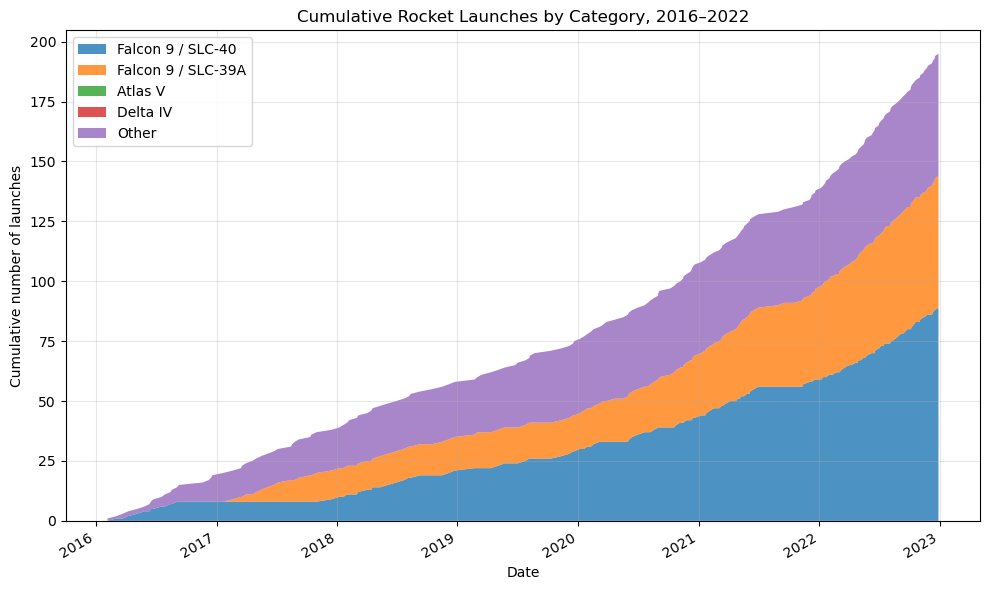

In [4]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# Make sure launches are in time order
df_plot = df.sort_values("window_start").copy()

# Define categories you want in the stacked cumulative plot
categories = [
    "Falcon 9 / SLC-40",
    "Falcon 9 / SLC-39A",
    "Atlas V",
    "Delta IV",
    "Other",
]

# Build a plotting category column
df_plot["plot_category"] = df_plot["family_pad_grouped"].copy()
df_plot.loc[~df_plot["plot_category"].isin(categories), "plot_category"] = "Other"

# Build cumulative columns
cum_df = pd.DataFrame({"window_start": df_plot["window_start"]})

for cat in categories:
    cum_df[cat] = (df_plot["plot_category"] == cat).astype(int).cumsum()

# Plot stacked cumulative area
fig, ax = plt.subplots(figsize=(10, 6))

ax.stackplot(
    cum_df["window_start"],
    [cum_df[cat] for cat in categories],
    labels=categories,
    alpha=0.8,
)

ax.set_title(f"Cumulative Rocket Launches by Category, {YEAR_MIN}–{YEAR_MAX}")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative number of launches")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left")
fig.autofmt_xdate()
fig.tight_layout()

fig.savefig(output_dir / "cumulative_launches_stacked_area.png", dpi=300, bbox_inches="tight")
fig.savefig(output_dir / "cumulative_launches_stacked_area.pdf", bbox_inches="tight")

plt.show()

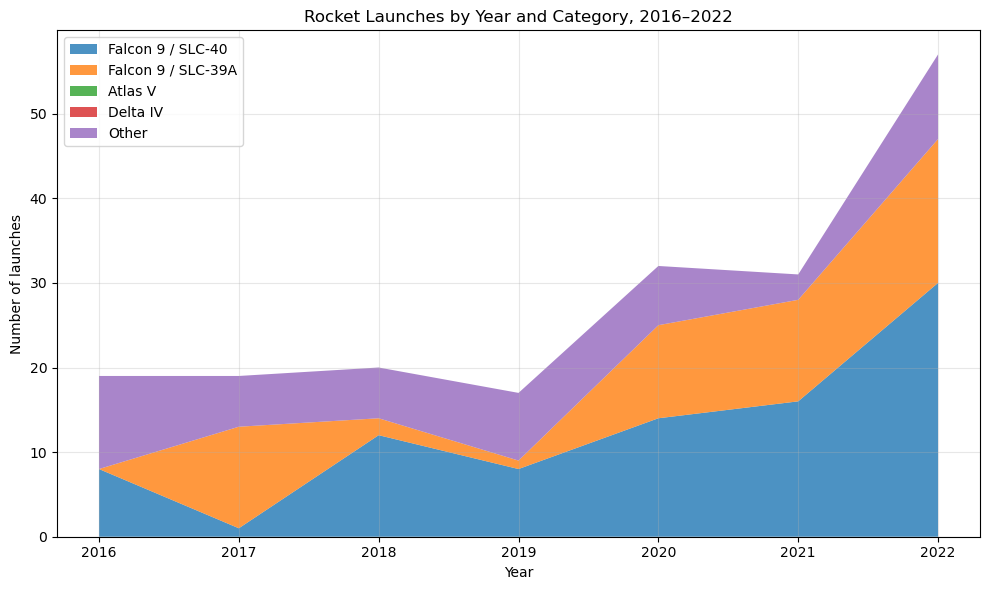

In [5]:
yearly = (
    df_plot.groupby(["year", "plot_category"])
    .size()
    .unstack(fill_value=0)
)

yearly = yearly.reindex(columns=categories, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 6))
ax.stackplot(
    yearly.index,
    [yearly[cat] for cat in categories],
    labels=categories,
    alpha=0.8,
)

ax.set_title(f"Rocket Launches by Year and Category, {YEAR_MIN}–{YEAR_MAX}")
ax.set_xlabel("Year")
ax.set_ylabel("Number of launches")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

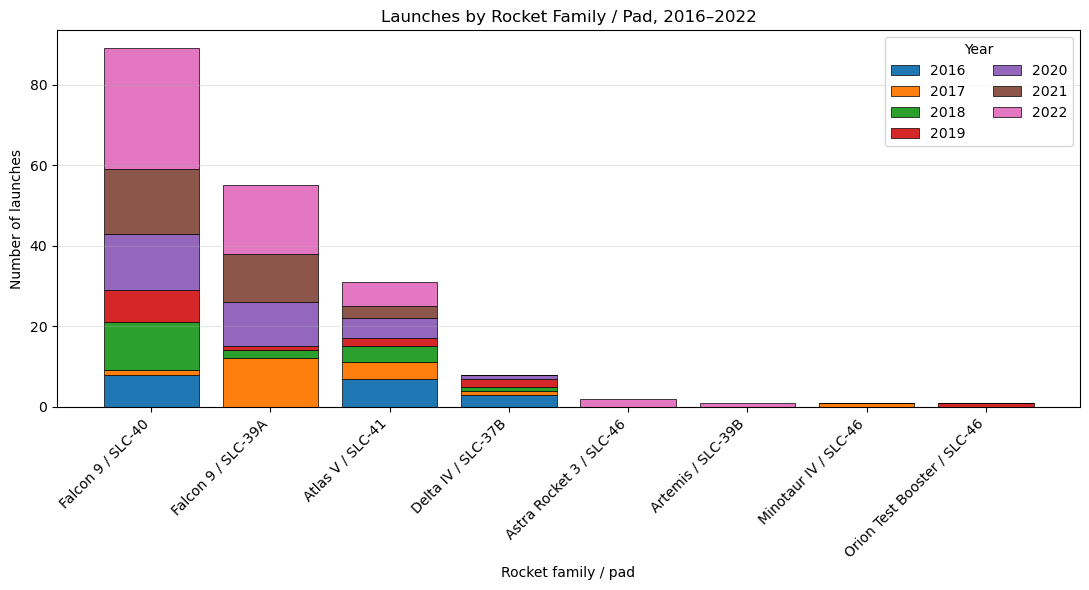

In [6]:
# -----------------------------------------------------------------------------
# Plot 2: launches by rocket family / pad, stacked by year
# -----------------------------------------------------------------------------
plot_df = (
    df_slc.groupby(["family_pad_grouped", "year"])
    .size()
    .unstack(fill_value=0)
)
import numpy as np
# Ensure years appear in order and all years are present
year_cols = list(range(YEAR_MIN, YEAR_MAX + 1))
plot_df = plot_df.reindex(columns=year_cols, fill_value=0)

# Optional: sort categories by total launches descending
plot_df["total"] = plot_df.sum(axis=1)
plot_df = plot_df.sort_values("total", ascending=False).drop(columns="total")

fig, ax = plt.subplots(figsize=(11, 6))

bottom = np.zeros(len(plot_df))

# Use a consistent colormap across years
cmap = plt.get_cmap("tab10")
colors = {year: cmap(i % 10) for i, year in enumerate(year_cols)}

for year in year_cols:
    values = plot_df[year].values
    ax.bar(
        plot_df.index,
        values,
        bottom=bottom,
        label=str(year),
        color=colors[year],
        edgecolor="black",
        linewidth=0.5,
    )
    bottom += values

ax.set_title(f"Launches by Rocket Family / Pad, {YEAR_MIN}–{YEAR_MAX}")
ax.set_xlabel("Rocket family / pad")
ax.set_ylabel("Number of launches")
ax.grid(True, axis="y", alpha=0.3)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
ax.legend(title="Year", ncol=2)
fig.tight_layout()

fig.savefig(output_dir / "launches_by_family_pad_stacked_by_year.png", dpi=300, bbox_inches="tight")
fig.savefig(output_dir / "launches_by_family_pad_stacked_by_year.pdf", bbox_inches="tight")

plt.show()

In [7]:
display(plot_df)

year,2016,2017,2018,2019,2020,2021,2022
family_pad_grouped,,,,,,,
Falcon 9 / SLC-40,8,1,12,8,14,16,30
Falcon 9 / SLC-39A,0,12,2,1,11,12,17
Atlas V / SLC-41,7,4,4,2,5,3,6
Delta IV / SLC-37B,3,1,1,2,1,0,0
Astra Rocket 3 / SLC-46,0,0,0,0,0,0,2
Artemis / SLC-39B,0,0,0,0,0,0,1
Minotaur IV / SLC-46,0,1,0,0,0,0,0
Orion Test Booster / SLC-46,0,0,0,1,0,0,0


In [8]:
# -----------------------------------------------------------------------------
# Build publication-quality table
# -----------------------------------------------------------------------------
table_df = plot_df.copy()

# Ensure integer counts
table_df = table_df.astype(int)

# Add row totals
table_df["Total"] = table_df.sum(axis=1)

# Add column totals
col_totals = table_df.sum(axis=0)
col_totals.name = "Total"

table_df = pd.concat([table_df, col_totals.to_frame().T])

# Rename index for clarity
table_df.index.name = "Rocket family / pad"

display(table_df)

year,2016,2017,2018,2019,2020,2021,2022,Total
Rocket family / pad,,,,,,,,
Falcon 9 / SLC-40,8,1,12,8,14,16,30,89
Falcon 9 / SLC-39A,0,12,2,1,11,12,17,55
Atlas V / SLC-41,7,4,4,2,5,3,6,31
Delta IV / SLC-37B,3,1,1,2,1,0,0,8
Astra Rocket 3 / SLC-46,0,0,0,0,0,0,2,2
Artemis / SLC-39B,0,0,0,0,0,0,1,1
Minotaur IV / SLC-46,0,1,0,0,0,0,0,1
Orion Test Booster / SLC-46,0,0,0,1,0,0,0,1
Total,18,19,19,14,31,31,56,188


In [9]:
excel_out = KSC_DIR / "table1_launches.xlsx"

with pd.ExcelWriter(excel_out, engine="openpyxl") as writer:
    table_df.to_excel(writer, sheet_name="Launches")

print(f"Saved to {excel_out}")

Saved to /Users/GlennThompson/Dropbox/KSC_paper/table1_launches.xlsx


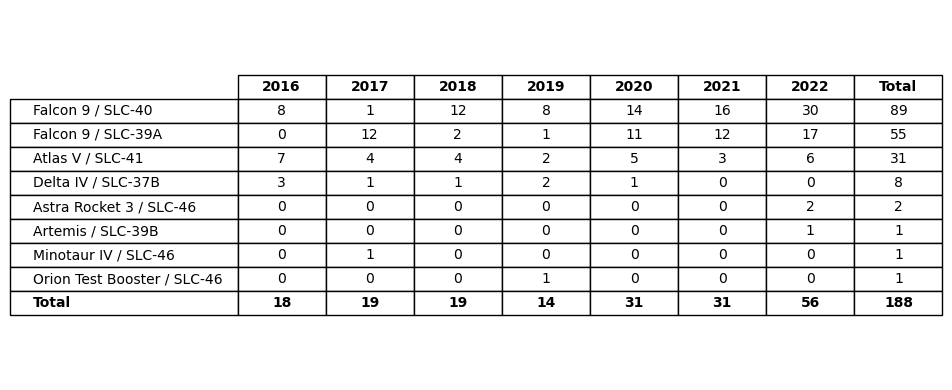

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis("off")

table = ax.table(
    cellText=table_df.values,
    rowLabels=table_df.index,
    colLabels=table_df.columns,
    loc="center",
    cellLoc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

# Bold header row
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")

# Bold last row
last_row = len(table_df)
for col in range(-1, len(table_df.columns)):
    if (last_row, col) in table.get_celld():
        table[(last_row, col)].set_text_props(weight="bold")

fig.tight_layout()

fig.savefig(KSC_DIR / "launches_table.png", dpi=300, bbox_inches="tight")
fig.savefig(KSC_DIR / "launches_table.pdf", bbox_inches="tight")

plt.show()